# OS Analysis

**This notebook analyzes overall survival in patients with BRAF-positive advanced melanoma treated with first-line combination immunotherpay or targeted therapy.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/ioio_tki_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
2090,FB1A4A8FF8EA7,tki,2015-05-14
440,F8E288AE36972,ioio,2021-09-23
2323,FEDF36253E778,tki,2019-08-09


In [4]:
treatment_df.shape

(2771, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'ioio').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/ioio_tki_features_df.csv', dtype = dtype_map)

In [7]:
features_df.head(3)

,PatientID,CalcResectInitialDx,TStage_mod,NStage_mod,MStage_mod,GroupStage_mod,ResidualDiseaseInitialDx_mod,ResidualDiseaseLocalRecur_mod,CalcResectLocalRecur_mod,days_diagnosis_to_adv,...,primary_site_procedure,lymph_node_procedure,other_viscera_met,thoracic_met,other_met,lymph_met,skin_met,bone_met,brain_met,liver_met
0,F744F618949B5,NaN,NaN,NaN,NaN,4.0,NaN,unknown,Unknown,0.0,...,0,0,1,1,1,0,1,0,0,0
1,F4AAE7EB8AE49,NaN,NaN,NaN,NaN,4.0,NaN,unknown,Unknown,0.0,...,0,0,0,0,0,0,0,1,0,1
2,F702FE1F825B7,Resectable,T3,N1,M0,3.0,R0,R0,Resectable,0.0,...,1,1,0,0,0,0,0,0,0,0


In [8]:
features_df.shape

(1339, 174)

In [9]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [10]:
df.shape

(1339, 177)

In [11]:
df = df.query('adv_diagnosis_year <= 2021')

In [12]:
df.shape

(1135, 177)

## Survival Analysis with IPTW

In [13]:
df.treatment.value_counts()

treatment
0    685
1    450
Name: count, dtype: int64

In [14]:
# Percent censoring
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.305109
1    0.555556
Name: event, dtype: float64

In [15]:
estimator = IPTWSurvivalEstimator()

In [16]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cont_var = ['days_adv_to_treatment', 'age', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'weight_index', 'percent_change_weight', 'albumin', 'total_bilirubin', 'ldh', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'medicaid', 'before_2020', 'brain_met', 'liver_met', 'GroupStage_mod_na', 'ecog_index_na', 'ses_mod_na'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False) 

In [17]:
iptw_df = estimator.transform()

In [18]:
ps_fig = estimator.propensity_score_plot(bins = 30)

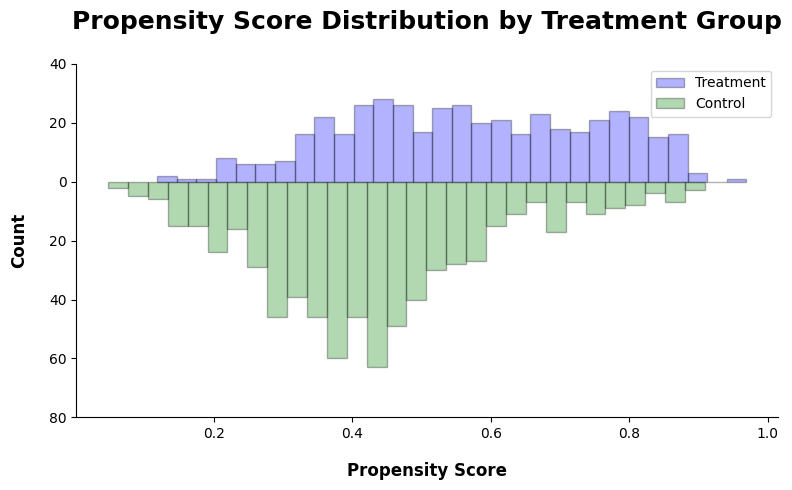

In [19]:
ps_fig

In [20]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

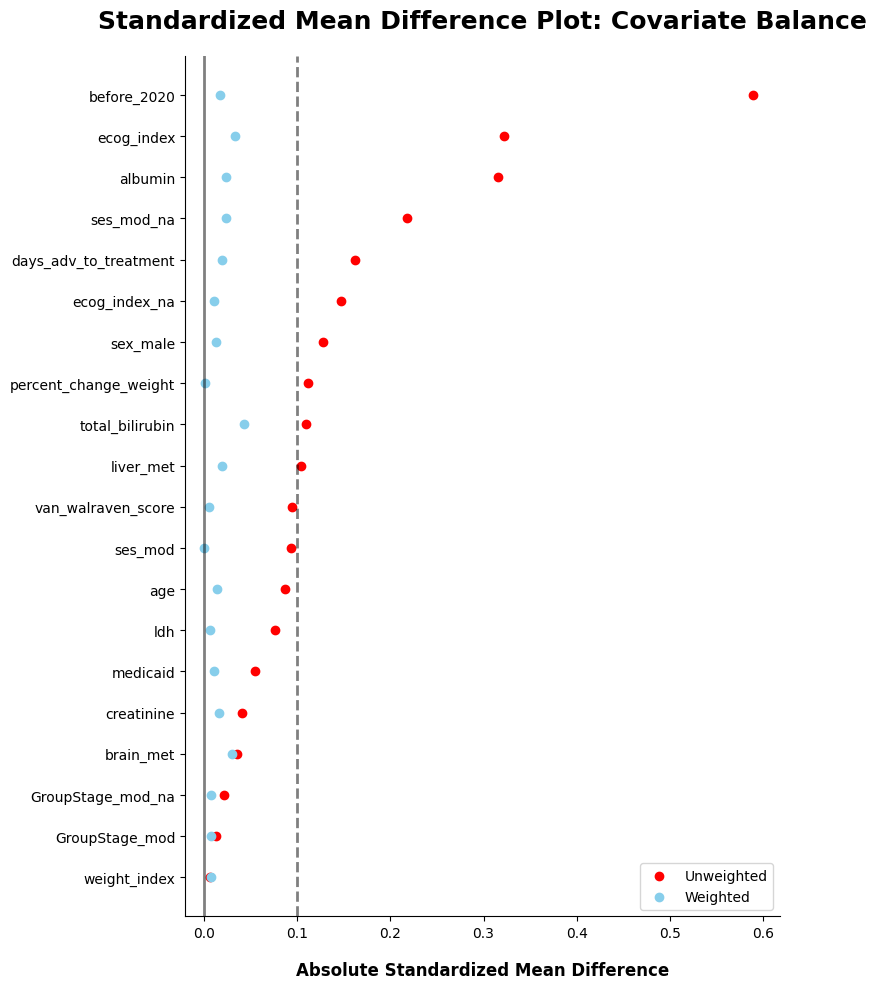

In [21]:
smd_fig

In [22]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [23]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [180, 365, 730],
                                     rmst_time_points = [180, 365, 730],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [24]:
# Median results
print('Median survival results')
print(f'IO-IO: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'TKI: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
IO-IO: (48.8, 33.2, 79.9) months
TKI: (16.0, 13.7, 18.2) months
Difference: (32.8, 16.5, 63.6) months


In [25]:
print('RMST results at 6 months')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][180])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][180])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][180])} days')

print('')
print('RMST results at 1 year')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

RMST results at 6 months
IO-IO: (156.1, 150.7, 161.4) days
TKI: (164.5, 161.6, 167.1) days
Difference: (-8.4, -14.0, -2.7) days

RMST results at 1 year
IO-IO: (293.8, 281.5, 305.9) days
TKI: (287.1, 278.0, 295.1) days
Difference: (6.7, -8.0, 20.9) days

RMST results at 2 years
IO-IO: (531.9, 504.2, 558.0) days
TKI: (459.0, 435.9, 480.2) days
Difference: (72.9, 38.5, 107.1) days


In [26]:
print('Probability of survival at 6 months')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][180])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][180])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][180])}')

print('')
print('Probability of survival at 1 year')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

Probability of survival at 6 months
IO-IO: (0.779, 0.737, 0.82)
TKI: (0.773, 0.737, 0.805)
Difference: (0.006, -0.045, 0.058)

Probability of survival at 1 year
IO-IO: (0.706, 0.658, 0.748)
TKI: (0.574, 0.529, 0.611)
Difference: (0.132, 0.073, 0.192)

Probability of survival at 2 years
IO-IO: (0.608, 0.559, 0.653)
TKI: (0.396, 0.35, 0.436)
Difference: (0.212, 0.151, 0.274)


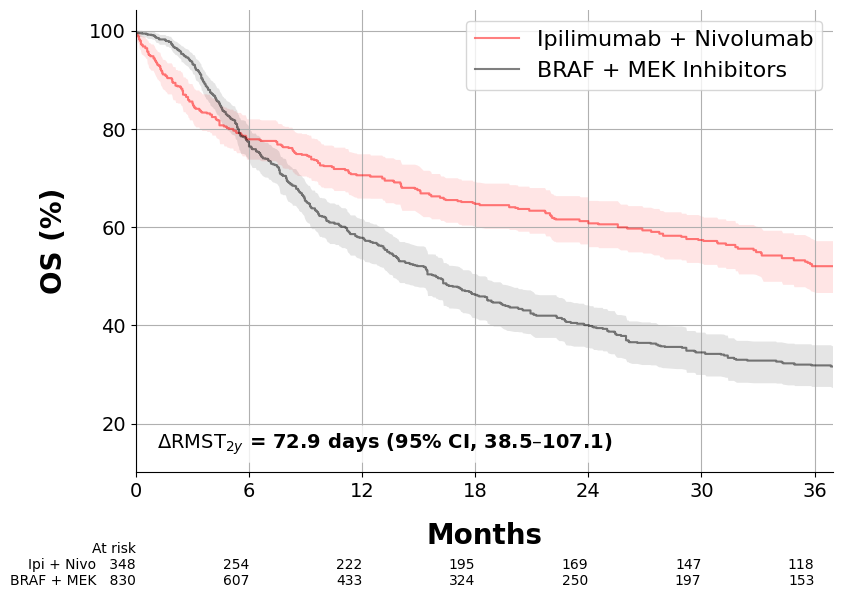

In [27]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Ipilimumab + Nivolumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='BRAF + MEK Inhibitors')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 37, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 37 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 2 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['Ipi + Nivo', 'BRAF + MEK'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_ioio_tki.pdf', format = 'pdf', bbox_inches = 'tight')